# USCD EDA by Khwezi Kunene


---

This dataset will explore the input files from https://cseweb.ucsd.edu/~jmcauley/datasets/goodreads.html

- English review subset for spoiler detection (1.3m book reviews about 25k books and 19k users, parsed at sentence-level): goodreads_reviews_spoiler.json.gz
- English review subset for spoiler detection (1.3m book reviews about 25k books and ~19k users, raw texts): goodreads_reviews_spoiler_raw.json.gz

## Imports and loading data

In [1]:
!pip install pandas numpy matplotlib seaborn tqdm
!pip install nltk spacy textstat wordcloud
!pip install sentence-transformers umap-learn bertopic
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 80.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [1]:
import json
import re
from collections import Counter
from tqdm import tqdm
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import nltk
nltk.download('vader_lexicon')
nltk.download('stopwords')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
REVIEW_FILE = "/content/drive/MyDrive/Colab Notebooks/Dissertation/UCSD/goodreads_reviews_spoiler_raw.json"
SPOILER_FILE = "/content/drive/MyDrive/Colab Notebooks/Dissertation/UCSD/goodreads_reviews_spoiler.json"

In [3]:
OUTPUT_DIR = Path("ucsd_eda_plots")
OUTPUT_DIR.mkdir(exist_ok=True)
RATING_PALETTE = ["#E05252", "#F5A623", "#F5D623", "#3DAA6E", "#5B7BE9"]

In [4]:
reviews = []

with open(REVIEW_FILE, "r") as f:
    for line in tqdm(f):
        reviews.append(json.loads(line))
review_df = pd.DataFrame(reviews)
#print(review_df.shape)
#review_df.head()

1378033it [00:27, 50119.91it/s]


In [7]:
spoilers = []

with open(SPOILER_FILE, "r") as f:
    for line in tqdm(f):
        spoilers.append(json.loads(line))
spoiler_df = pd.DataFrame(spoilers)
print(spoiler_df.shape)
spoiler_df.head()

1378033it [01:08, 19999.08it/s]


(1378033, 7)


,user_id,timestamp,review_sentences,rating,has_spoiler,book_id,review_id
0,8842281e1d1347389f2ab93d60773d4d,2017-08-30,"[[0, This is a special book.], [0, It started ...",5,True,18245960,dfdbb7b0eb5a7e4c26d59a937e2e5feb
1,8842281e1d1347389f2ab93d60773d4d,2017-03-22,"[[0, Recommended by Don Katz.], [0, Avail for ...",3,False,16981,a5d2c3628987712d0e05c4f90798eb67
2,8842281e1d1347389f2ab93d60773d4d,2017-03-20,"[[0, A fun, fast paced science fiction thrille...",3,True,28684704,2ede853b14dc4583f96cf5d120af636f
3,8842281e1d1347389f2ab93d60773d4d,2016-11-09,"[[0, Recommended reading to understand what is...",0,False,27161156,ced5675e55cd9d38a524743f5c40996e
4,8842281e1d1347389f2ab93d60773d4d,2016-04-25,"[[0, I really enjoyed this book, and there is ...",4,True,25884323,332732725863131279a8e345b63ac33e


## Helper functions


---


The helper functions will assist with managing the plots and getting stats like average sentence length, token information


In [8]:
def save(fig: plt.Figure, name: str) -> None:
    path = OUTPUT_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    print(f"  Saved → {path}")
    plt.close(fig)


def fmt_k(x, _=None) -> str:
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    if x >= 1_000:
        return f"{x/1_000:.0f}K"
    return str(int(x))


def count_syllables(word: str) -> int:
    word = word.lower().rstrip("e")
    return max(1, len(re.findall(r"[aeiouy]+", word)))


def ttr(text: str) -> float:
    """Type-Token Ratio — lexical diversity."""
    tokens = re.findall(r"\b\w+\b", text.lower())
    return len(set(tokens)) / len(tokens) if tokens else 0.0


def flesch(text: str) -> float:
    """Flesch Reading Ease (approximate)."""
    words = re.findall(r"\b\w+\b", text)
    sents = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    sylls = sum(count_syllables(w) for w in words)
    nw, ns = len(words), len(sents)
    if nw == 0 or ns == 0:
        return 0.0
    return 206.835 - 1.015 * (nw / ns) - 84.6 * (sylls / nw)


def gini(arr: np.ndarray) -> float:
    """Gini coefficient — measures inequality of a distribution."""
    arr = np.sort(arr.astype(float))
    n = len(arr)
    if n == 0 or arr.sum() == 0:
        return 0.0
    return (2 * np.sum(np.arange(1, n + 1) * arr) - (n + 1) * arr.sum()) / (n * arr.sum())


def missing_pct(series: pd.Series) -> float:
    return (
        series.isna()
        | (series.astype(str).str.strip() == "")
        | (series.astype(str) == "[]")
        | (series.astype(str) == "{}")
    ).mean() * 100

## Step 1 - Ratings Distribution


Reviews ratings ★

In [9]:
def rating_distribution(reviews: pd.DataFrame, eng_books: pd.DataFrame) -> None:
    print("Step 1: Rating distribution")

    rating_counts = reviews["rating"].value_counts().sort_index()
    print("  Review ratings:")
    for r, c in rating_counts.items():
        print(f"    {r}★  {c:>8,}  ({c/len(reviews)*100:.1f}%)")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle("Step 1 — Rating distributions", fontsize=13)

    # Review star ratings
    axes[0].bar(rating_counts.index, rating_counts.values,
                color=RATING_PALETTE, alpha=0.85, edgecolor="white", linewidth=0.5)
    axes[0].set_title("Review star ratings")
    axes[0].set_xlabel("Stars")
    axes[0].set_ylabel("Reviews")
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
    for r, c in rating_counts.items():
        axes[0].text(r, c + rating_counts.max() * 0.01,
                     f"{c/len(reviews)*100:.1f}%", ha="center", fontsize=9)

    # Book average rating from metadata
    eng_books = eng_books.copy()
    eng_books["average_rating"] = pd.to_numeric(eng_books["average_rating"], errors="coerce")
    data_avg = eng_books["average_rating"].dropna()
    axes[1].hist(data_avg, bins=40, color="#5B7BE9", alpha=0.8, edgecolor="white")
    axes[1].axvline(data_avg.mean(), color="#E05252", linestyle="--", linewidth=1.5,
                    label=f"mean={data_avg.mean():.2f}")
    axes[1].set_title("Book average rating (Goodreads metadata)")
    axes[1].set_xlabel("Average rating")
    axes[1].set_ylabel("Books")
    axes[1].legend()

    fig.tight_layout()
    plt.show()
    save(fig, "step1_rating_distributions")

    print(f"\n  Mean review rating  : {reviews['rating'].mean():.3f}")
    print(f"  Median              : {reviews['rating'].median():.1f}")
    print(f"  % 4-5 star reviews  : {(reviews['rating'] >= 4).mean()*100:.1f}%")
    print(f"  % 1-2 star reviews  : {(reviews['rating'] <= 2).mean()*100:.1f}%")

## Review Length

In [10]:
def review_length(reviews: pd.DataFrame) -> None:
    print("Step 2: Review length distribution")

    wc_99 = reviews["word_count"].quantile(0.99)
    sc_99 = reviews["n_sentences"].quantile(0.99)

    print(f"  Word count  — median: {reviews['word_count'].median():.0f}  "
          f"mean: {reviews['word_count'].mean():.0f}  "
          f"99th pct: {wc_99:.0f}")
    print(f"  Sent count  — median: {reviews['n_sentences'].median():.0f}  "
          f"mean: {reviews['n_sentences'].mean():.0f}")
    print(f"  Reviews with 0 words : {(reviews['word_count']==0).mean()*100:.1f}%")
    print(f"  Reviews ≥50 words    : {(reviews['word_count']>=50).mean()*100:.1f}%")
    print(f"  Reviews ≥100 words   : {(reviews['word_count']>=100).mean()*100:.1f}%")

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle("Step 2 — Review length distributions", fontsize=13)

    # 2a: Word count histogram
    data_wc = reviews[reviews["word_count"].between(1, wc_99)]["word_count"]
    axes[0, 0].hist(data_wc, bins=50, color="#5B7BE9", alpha=0.8, edgecolor="white")
    axes[0, 0].axvline(data_wc.median(), color="#E05252", linestyle="--", linewidth=1.5,
                       label=f"median={data_wc.median():.0f}")
    axes[0, 0].axvline(50, color="#F5A623", linestyle=":", linewidth=1.2, label="50 words")
    axes[0, 0].set_title(f"Word count per review (≤99th pct = {wc_99:.0f})")
    axes[0, 0].set_xlabel("Word count")
    axes[0, 0].set_ylabel("Reviews")
    axes[0, 0].legend(fontsize=9)
    axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

    # 2b: Sentence count histogram
    data_sc = reviews[reviews["n_sentences"].between(1, sc_99)]["n_sentences"]
    axes[0, 1].hist(data_sc, bins=40, color="#3DAA6E", alpha=0.8, edgecolor="white")
    axes[0, 1].axvline(data_sc.median(), color="#E05252", linestyle="--", linewidth=1.5,
                       label=f"median={data_sc.median():.0f}")
    axes[0, 1].set_title(f"Sentence count per review (≤99th pct = {sc_99:.0f})")
    axes[0, 1].set_xlabel("Sentences")
    axes[0, 1].set_ylabel("Reviews")
    axes[0, 1].legend(fontsize=9)

    # 2c: Word count by star rating (violin)
    plot_data = reviews[reviews["word_count"].between(1, int(wc_99))].copy()
    sns.violinplot(data=plot_data, x="rating", y="word_count",
                   palette=RATING_PALETTE, inner="quart", ax=axes[1, 0])
    axes[1, 0].set_title("Review word count by star rating")
    axes[1, 0].set_xlabel("Star rating")
    axes[1, 0].set_ylabel("Word count")

    sorted_wc = np.sort(reviews["word_count"].values)
    # 2d: Log-scale CDF
    axes[1, 1].plot(sorted_wc, np.arange(len(sorted_wc)) / len(sorted_wc),
                    color="#5B7BE9", linewidth=1.5)
    for cutoff, label, color in [(50, "50w", "#F5A623"), (100, "100w", "#3DAA6E"),
                                  (500, "500w", "#E05252")]:
        pct = (reviews["word_count"] <= cutoff).mean()
        axes[1, 1].axvline(cutoff, linestyle=":", color=color, linewidth=1.2,
                           label=f"{label} ({pct*100:.0f}%)")
    axes[1, 1].set_xscale("log")
    axes[1, 1].set_title("CDF of review word count (log scale)")
    axes[1, 1].set_xlabel("Word count (log)")
    axes[1, 1].set_ylabel("Cumulative fraction")
    axes[1, 1].legend(fontsize=9)

    fig.tight_layout()
    plt.show()
    save(fig, "step2_review_length")

    # Kruskal-Wallis: does word count vary with rating?
    groups = [reviews[reviews["rating"] == r]["word_count"].values for r in range(1, 6)]
    stat, pval = stats.kruskal(*[g for g in groups if len(g) > 0])
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    print(f"\n  Kruskal-Wallis (word count ~ rating): H={stat:.2f}  p={pval:.2e}  {sig}")

## Genre distribution

In [11]:
def step4_genre_shelves(eng_books: pd.DataFrame) -> None:
    print("Genre / shelf distribution─")

    def parse_shelves(shelf_list):
        if not isinstance(shelf_list, list):
            return []
        return [(s.get("name", ""), int(s.get("count", 0)))
                for s in shelf_list if isinstance(s, dict)]

    eng_books = eng_books.copy()
    eng_books["parsed_shelves"] = eng_books["popular_shelves"].apply(parse_shelves)

    shelf_counter = Counter()
    for shelves in eng_books["parsed_shelves"]:
        for name, count in shelves:
            shelf_counter[name] += count

    top_shelves = pd.DataFrame(shelf_counter.most_common(40), columns=["shelf", "count"])
    print(f"  Unique shelves: {len(shelf_counter):,}")
    print("\n  Top 20:")
    print(top_shelves.head(20).to_string(index=False))

    # Top 30 shelves
    top30 = top_shelves.head(30)
    fig, ax = plt.subplots(figsize=(10, 9))
    ax.barh(top30["shelf"][::-1], top30["count"][::-1], color="#5B7BE9", alpha=0.8)
    ax.set_title("Step 4 — Top 30 Goodreads shelves (total shelf count across English books)")
    ax.set_xlabel("Total count")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
    fig.tight_layout()
    plt.show()
    save(fig, "step4a_top_shelves")

    # ── 4b: Shelf co-occurrence (top 10) ─────────────────────────────────
    print("\n  Computing shelf co-occurrence matrix for top 10 ...")
    top10 = top_shelves["shelf"].head(10).tolist()
    cooc = pd.DataFrame(0, index=top10, columns=top10)
    for shelves in eng_books["parsed_shelves"]:
        names = {n for n, _ in shelves}
        present = [s for s in top10 if s in names]
        for i, a in enumerate(present):
            for b in present[i:]:
                cooc.loc[a, b] += 1
                if a != b:
                    cooc.loc[b, a] += 1

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cooc, annot=True, fmt=",", cmap="Blues",
                linewidths=0.5, ax=ax, cbar_kws={"label": "Books on both shelves"})
    ax.set_title("Shelf co-occurrence (top 10 genres)")
    fig.tight_layout()
    plt.show()
    save(fig, "step4b_shelf_cooccurrence")

    # Books per top shelf
    top10_coverage = {
        s: eng_books["parsed_shelves"].apply(
            lambda sl: any(n == s for n, _ in sl)
        ).sum()
        for s in top10
    }
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(list(top10_coverage.keys()), list(top10_coverage.values()),
           color="#3DAA6E", alpha=0.85)
    ax.set_title("Books that appear on each top-10 shelf")
    ax.set_ylabel("Books")
    ax.tick_params(axis="x", rotation=35)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
    fig.tight_layout()

    plt.show()
    save(fig, "step4c_shelf_coverage")

## Review Text Quality Signals

In [6]:
def text_quality_signal(reviews: pd.DataFrame, sample_n: int = 50_000) -> pd.DataFrame:
    print("Review text quality signals")

    #reviews["word_count"] = reviews["review_text"].apply(lambda t: len(re.findall(r"\b\w+\b", t)))
    review_df["word_count"] = (review_df["review_text"] .fillna("") .astype(str).str.split().str.len())

    try:
        sia = SentimentIntensityAnalyzer()
        vader_available = True
    except ImportError:
        print("  WARNING: vaderSentiment not installed. Skipping sentiment analysis.")
        print("  Install: pip install vaderSentiment")
        vader_available = False

    # Work on a text subsample for speed
    rev_text = reviews[reviews["word_count"] > 5].copy()
    if len(rev_text) > sample_n:
        rev_text = rev_text.sample(sample_n, random_state=42)

    print(f"  Computing text features for {len(rev_text):,} reviews ...")

    print("  → TTR ...")
    rev_text["ttr"] = rev_text["review_text"].apply(ttr)

    print("  → Flesch reading ease ...")
    rev_text["flesch"] = rev_text["review_text"].apply(flesch)

    if vader_available:
        print("  → VADER sentiment ...")
        scores = rev_text["review_text"].apply(lambda t: sia.polarity_scores(t))
        rev_text["vader_compound"] = scores.apply(lambda s: s["compound"])
        rev_text["vader_pos"] = scores.apply(lambda s: s["pos"])
        rev_text["vader_neg"] = scores.apply(lambda s: s["neg"])

    # Distribution plots
    feat_labels = [
        ("ttr", "Type-Token Ratio (lexical diversity)"),
        ("flesch", "Flesch Reading Ease"),
    ]
    if vader_available:
        feat_labels += [("vader_compound", "VADER compound sentiment (−1 to +1)")]

    n_feats = len(feat_labels)
    fig, axes = plt.subplots(2, n_feats, figsize=(5 * n_feats, 9))
    fig.suptitle("Step 5 — Review text quality signals", fontsize=13)

    for col_i, (feat, label) in enumerate(feat_labels):
        # Row 0: histogram
        data = rev_text[feat].dropna()
        axes[0, col_i].hist(data, bins=40, color="#5B7BE9", alpha=0.8, edgecolor="white")
        axes[0, col_i].axvline(data.median(), color="#E05252", linestyle="--",
                                linewidth=1.5, label=f"median={data.median():.2f}")
        axes[0, col_i].set_title(label, fontsize=10)
        axes[0, col_i].legend(fontsize=8)

        # Row 1: feature vs rating box plot
        sns.boxplot(data=rev_text, x="rating", y=feat,
                    palette=RATING_PALETTE,
                    ax=axes[1, col_i], linewidth=0.8, fliersize=1)
        axes[1, col_i].set_title(f"{label}\nby star rating", fontsize=10)
        axes[1, col_i].set_xlabel("Star rating")

    fig.tight_layout()
    plt.show()
    save(fig, "step5_text_quality_signals")

    # Correlation table
    text_feats = ["word_count", "ttr", "flesch"]
    if vader_available:
        text_feats += ["vader_compound", "vader_pos", "vader_neg"]

    print("\n  Spearman ρ with star rating:")
    for f in text_feats:
        if f not in rev_text.columns:
            continue
        sub = rev_text[["rating", f]].dropna()
        r, p = stats.spearmanr(sub["rating"], sub[f])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        print(f"  {f:22s}  ρ={r:+.3f}  p={p:.2e}  {sig}")

    # VADER sentiment by rating
    if vader_available:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        by_rating = rev_text.groupby("rating")[["vader_compound", "vader_neg"]].mean()
        axes[0].bar(by_rating.index, by_rating["vader_compound"],
                    color=RATING_PALETTE, alpha=0.85)
        axes[0].set_title("Mean VADER compound sentiment by rating")
        axes[0].set_xlabel("Star rating")
        axes[0].set_ylabel("Compound score")

        axes[1].bar(by_rating.index, by_rating["vader_neg"],
                    color=RATING_PALETTE, alpha=0.85)
        axes[1].set_title("Mean VADER negativity score by rating")
        axes[1].set_xlabel("Star rating")
        axes[1].set_ylabel("Negativity score")

        fig.tight_layout()
        plt.show()
        save(fig, "step5b_vader_by_rating")

    return rev_text

## User Activity distribution

In [13]:
def user_activity(reviews: pd.DataFrame) -> None:
    print("User activity distribution")

    user_counts = reviews.groupby("user_id").size().reset_index(name="n_reviews")
    book_counts = reviews.groupby("book_id").size().reset_index(name="n_reviews")

    g_users = gini(user_counts["n_reviews"].values)
    g_books = gini(book_counts["n_reviews"].values)

    print("  Reviews per user:")
    print(user_counts["n_reviews"].describe().round(1).to_string())
    print(f"\n  Users with 1 review    : {(user_counts['n_reviews']==1).mean()*100:.1f}%")
    print(f"  Users with ≥10 reviews : {(user_counts['n_reviews']>=10).mean()*100:.1f}%")
    print(f"  Users with ≥50 reviews : {(user_counts['n_reviews']>=50).mean()*100:.1f}%")
    print(f"\n  Gini coefficient (users) : {g_users:.3f}")
    print(f"  Gini coefficient (books) : {g_books:.3f}")
    print("  → Higher Gini = more skewed; consider per-user cap during sampling")

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle("Step 7 — User & book activity distributions", fontsize=13)

    # 7a: User review count log-log CCDF
    user_sorted = np.sort(user_counts["n_reviews"].values)[::-1]
    axes[0, 0].loglog(np.arange(1, len(user_sorted) + 1), user_sorted,
                      color="#5B7BE9", linewidth=1.5)
    axes[0, 0].set_title("User review count — log-log CCDF")
    axes[0, 0].set_xlabel("User rank")
    axes[0, 0].set_ylabel("Reviews written")

    # 7b: Reviews per user histogram
    cap_u = user_counts["n_reviews"].quantile(0.99)
    data_u = user_counts[user_counts["n_reviews"] <= cap_u]["n_reviews"]
    axes[0, 1].hist(data_u, bins=50, color="#5B7BE9", alpha=0.8, edgecolor="white")
    axes[0, 1].axvline(data_u.median(), color="#E05252", linestyle="--",
                       linewidth=1.5, label=f"median={data_u.median():.0f}")
    axes[0, 1].set_title(f"Reviews per user (≤99th pct = {int(cap_u)})")
    axes[0, 1].set_xlabel("Reviews written")
    axes[0, 1].set_ylabel("Users")
    axes[0, 1].legend()
    axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

    # 7c: Reviews per book histogram
    cap_b = book_counts["n_reviews"].quantile(0.99)
    data_b = book_counts[book_counts["n_reviews"] <= cap_b]["n_reviews"]
    axes[1, 0].hist(data_b, bins=50, color="#3DAA6E", alpha=0.8, edgecolor="white")
    axes[1, 0].axvline(data_b.median(), color="#E05252", linestyle="--",
                       linewidth=1.5, label=f"median={data_b.median():.0f}")
    axes[1, 0].set_title(f"Reviews per book (≤99th pct = {int(cap_b)})")
    axes[1, 0].set_xlabel("Reviews received")
    axes[1, 0].set_ylabel("Books")
    axes[1, 0].legend()
    axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))

    # Lorenz curve
    def lorenz(arr):
        s = np.sort(arr.astype(float))
        n = len(s)
        cs = np.cumsum(s)
        return np.linspace(0, 1, n), cs / cs[-1]

    lx_u, ly_u = lorenz(user_counts["n_reviews"].values)
    lx_b, ly_b = lorenz(book_counts["n_reviews"].values)
    axes[1, 1].plot(lx_u, ly_u, color="#5B7BE9", linewidth=2, label=f"Users (Gini={g_users:.2f})")
    axes[1, 1].plot(lx_b, ly_b, color="#3DAA6E", linewidth=2, label=f"Books (Gini={g_books:.2f})")
    axes[1, 1].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Perfect equality")
    axes[1, 1].fill_between(lx_u, ly_u, lx_u, alpha=0.1, color="#5B7BE9")
    axes[1, 1].set_title("Lorenz curve — review inequality")
    axes[1, 1].set_xlabel("Cumulative fraction of users/books")
    axes[1, 1].set_ylabel("Cumulative fraction of reviews")
    axes[1, 1].legend(fontsize=9)

    fig.tight_layout()
    plt.show()
    save(fig, "step7_user_activity")

## Summary

In [14]:
def print_summary(reviews: pd.DataFrame, eng_books: pd.DataFrame) -> None:
    g_u = gini(reviews.groupby("user_id").size().values)
    g_b = gini(reviews.groupby("book_id").size().values)
    desc_wc = eng_books["description"].fillna("").apply(
        lambda t: len(re.findall(r"\b\w+\b", str(t)))
    )

    print("\n" + "=" * 65)
    print("  UCSD Goodreads EDA — Key findings")
    print("=" * 65)
    print(f"""
  English books loaded          : {len(eng_books):,}
  Reviews loaded (English)      : {len(reviews):,}
  Unique users (sample)         : {reviews['user_id'].nunique():,}
  Unique books reviewed         : {reviews['book_id'].nunique():,}

  Rating
    Mean                        : {reviews['rating'].mean():.2f} / 5
    % 4-5★ reviews              : {(reviews['rating']>=4).mean()*100:.1f}%

  Review length
    Median word count           : {reviews['word_count'].median():.0f}
    % reviews with ≥50 words    : {(reviews['word_count']>=50).mean()*100:.1f}%
    % reviews with ≥100 words   : {(reviews['word_count']>=100).mean()*100:.1f}%

  Spoilers
    Review-level spoiler rate   : {reviews['has_spoiler'].mean()*100:.1f}%

  Metadata
    Books with description>10w  : {(desc_wc>10).mean()*100:.1f}%

  Activity skew
    Gini — users                : {g_u:.3f}
    Gini — books                : {g_b:.3f}
""")
    print(f"  All plots saved to → {OUTPUT_DIR.resolve()}/")
    print("=" * 65)

## Run the full EDA

In [15]:
print("\nREVIEW COLUMNS")
print(review_df.columns.tolist())

print("\nSPOILER COLUMNS")
print(spoiler_df.columns.tolist())


REVIEW COLUMNS
['user_id', 'book_id', 'review_id', 'rating', 'review_text', 'date_added', 'date_updated', 'read_at', 'started_at', 'n_votes', 'n_comments']

SPOILER COLUMNS
['user_id', 'timestamp', 'review_sentences', 'rating', 'has_spoiler', 'book_id', 'review_id']


In [ ]:
rating_distribution(reviews, eng_books)

In [ ]:
review_length(reviews_df)

In [ ]:
genre_shelves(eng_books)

In [ ]:
text_quality_signal(review_df)

Review text quality signals


Step 7: User activity distribution
  Reviews per user:
count    18892.0
mean        72.9
std        102.7
min          1.0
25%         14.0
50%         36.0
75%         90.0
max       1815.0

  Users with 1 review    : 2.0%
  Users with ≥10 reviews : 81.8%
  Users with ≥50 reviews : 41.3%

  Gini coefficient (users) : 0.599
  Gini coefficient (books) : 0.577
  → Higher Gini = more skewed; consider per-user cap during sampling


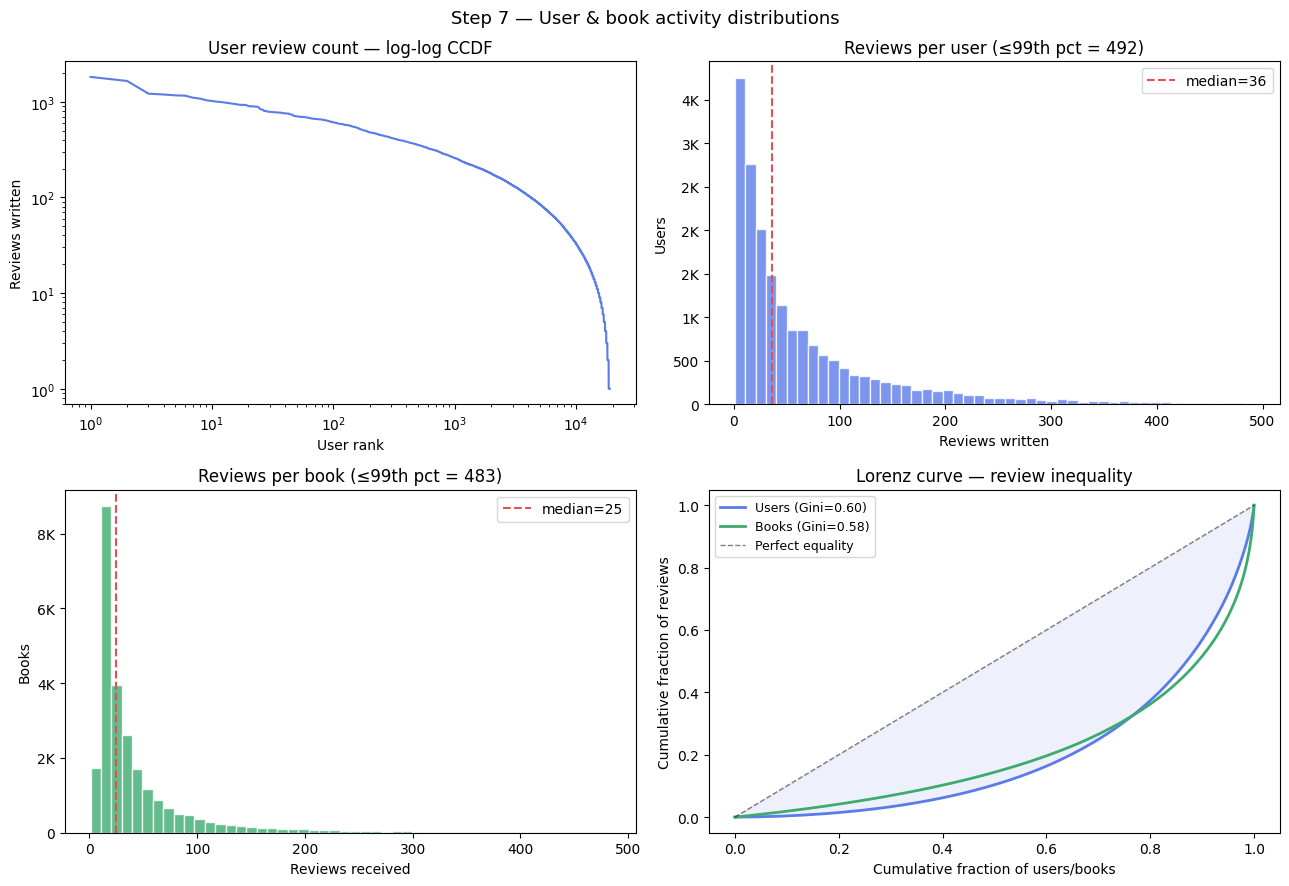

  Saved → ucsd_eda_plots/step7_user_activity.png


In [ ]:
user_activity(review_df)